# 🌌 Simulating Relativistic Orbits with EinsteinEngine

In this notebook, we demonstrate the ultimate goal of **EinsteinEngine**: bridging the gap between pure abstract mathematics and numerical physics. 

We will:
1. Define a Schwarzschild Black Hole space-time.
2. Use our C++ backend to compute the exact relativistic equations of motion (Geodesics).
3. Feed these symbolic equations into a numerical integrator (`scipy.integrate`).
4. Visualize the famous **perihelion precession** (the "rosette" orbit) that proved Albert Einstein's General Relativity.

In [14]:
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from IPython.display import display, Math

from einsteinengine.symbolic.metric import MetricTensor 
from einsteinengine.symbolic.christoffel import ChristoffelSymbols 
from einsteinengine.symbolic.geodesics import Geodesics 

print("All libraries loaded successfully. Ready to compute.")

All libraries loaded successfully. Ready to compute.


## 1. Defining the Space-Time

First, we define the mathematical symbols and the covariant metric tensor array $g_{\mu\nu}$ for a non-rotating Black Hole (Schwarzschild Metric).

In [15]:
# Define coordinates and mass
t, r, theta, phi = sp.symbols('t r theta phi', real=True)
M = sp.symbols('M', real=True, positive=True)
syms = [t, r, theta, phi]

# Define the Schwarzschild metric array
g_schwarzschild = [
    [-(1 - 2*M/r), 0, 0, 0],
    [0, 1/(1 - 2*M/r), 0, 0],
    [0, 0, r**2, 0],
    [0, 0, 0, r**2 * sp.sin(theta)**2]
]

# Instantiate the Metric Tensor
metric = MetricTensor(g_schwarzschild, syms, name="Schwarzschild", verbose=False)

## 2. Computing the Geodesic Equations

We now delegate the heavy lifting to our engine. It will compute the inverse metric, the 64 Christoffel symbols, and build the algebraic equations of motion. We set `substitute_velocities=True` to extract pure algebraic formulas ready for numerical evaluation.

In [16]:
# Compute the Christoffel Symbols (The gravitational "forces")
christoffel = ChristoffelSymbols.from_metric(metric, verbose=False)

# Generate the algebraic geodesic equations
geo = Geodesics(christoffel, param_name="tau", verbose=False)

# We set simplify=False to retrieve the raw high-performance SymEngine objects
accelerations = geo.get_equations(substitute_velocities=True, simplify=False)

# Display the exact radial acceleration (index 1 is 'r') calculated by the engine
display(Math(r"\text{Radial Acceleration generated by the engine: }"))
display(Math(f"a_r = {sp.latex(sp.simplify(sp.sympify(accelerations[1])))}"))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

## 3. The Fully Automated Numerical Bridge (`lambdify`)

Instead of manually typing the effective physics formulas, we will programmatically extract the exact outputs from `EinsteinEngine` and compile them into high-speed C/Python functions using `sympy.lambdify`. 

**The Power of General Relativity:**
Unlike Newtonian mechanics, in General Relativity time is dynamic. The radial acceleration $d^2r/d\tau^2$ inherently depends on the time-velocity $v_t = dt/d\tau$. Therefore, to simulate the orbit properly, we must integrate the full coupled system of ODEs for time ($t$), radius ($r$), and angle ($\phi$).

In [18]:
from sympy import lambdify

# 1. Convert engine outputs to SymPy expressions safely
a_t_expr = sp.sympify(accelerations[0])
a_r_expr = sp.sympify(accelerations[1])
a_phi_expr = sp.sympify(accelerations[3])

# 2. Safe String Substitution to avoid memory ID mismatches
# We set Black Hole Mass M = 1.0 and confine the orbit to the equator (theta = pi/2)
subs_dict = {'M': 1.0, 'theta': sp.pi/2, 'v_theta': 0.0}

a_t_eq = sp.simplify(a_t_expr.subs(subs_dict))
a_r_eq = sp.simplify(a_r_expr.subs(subs_dict))
a_phi_eq = sp.simplify(a_phi_expr.subs(subs_dict))

# 3. Extract the exact symbols from the simplified expressions 
# This guarantees lambdify uses the exact same objects the engine used
all_exprs = a_t_eq + a_r_eq + a_phi_eq
sym_map = {s.name: s for s in all_exprs.free_symbols}

r_s = sym_map['r']
vt_s = sym_map['v_t']
vr_s = sym_map['v_r']
vphi_s = sym_map['v_phi']

# 4. LAMBDIFY: Compile the 3 differential equations
calc_a_t = lambdify([r_s, vt_s, vr_s, vphi_s], a_t_eq, 'numpy')
calc_a_r = lambdify([r_s, vt_s, vr_s, vphi_s], a_r_eq, 'numpy')
calc_a_phi = lambdify([r_s, vt_s, vr_s, vphi_s], a_phi_eq, 'numpy')

# 5. Define the full SciPy ODE system
def orbit_eqs_automated(tau, state):
    # State vector: [t, v_t, r, v_r, phi, v_phi]
    t_curr, vt_curr, r_curr, vr_curr, phi_curr, vphi_curr = state
    
    # Evaluate accelerations dynamically using EinsteinEngine's compiled core
    at_val = calc_a_t(r_curr, vt_curr, vr_curr, vphi_curr)
    ar_val = calc_a_r(r_curr, vt_curr, vr_curr, vphi_curr)
    aphi_val = calc_a_phi(r_curr, vt_curr, vr_curr, vphi_curr)
    
    # Return derivatives: [dt/dtau, dv_t/dtau, dr/dtau, dv_r/dtau, dphi/dtau, dv_phi/dtau]
    return [vt_curr, at_val, vr_curr, ar_val, vphi_curr, aphi_val]

# 6. Physical Initial Conditions
initial_r = 18.0
L = 3.9 
initial_v_phi = L / (initial_r**2)

# VERY IMPORTANT: Calculate the valid initial Time-Velocity (v_t)
# In GR, a massive particle must satisfy the 4-velocity norm: g_uv * v^u * v^v = -1
M_val = 1.0
g_tt = -(1.0 - 2.0 * M_val / initial_r)
g_phiphi = initial_r**2

# Solve for v_t: g_tt * (v_t)^2 + g_phiphi * (v_phi)^2 = -1
vt_squared = (-1.0 - g_phiphi * (initial_v_phi**2)) / g_tt
initial_v_t = np.sqrt(vt_squared)

# Initialize state: [t, v_t, r, v_r, phi, v_phi]
initial_state = [0.0, initial_v_t, initial_r, 0.0, 0.0, initial_v_phi]

print("Compiling and running fully automated 4D simulation...")

# 7. Run SciPy
solution = solve_ivp(
    orbit_eqs_automated, 
    [0, 3000], 
    initial_state, 
    t_eval=np.linspace(0, 3000, 15000),
    method='RK45'
)

# Extract coordinates for plotting (Indices 2 and 4 correspond to r and phi)
r_sol = solution.y[2]
phi_sol = solution.y[4]
proper_time = solution.t

x = r_sol * np.cos(phi_sol)
y = r_sol * np.sin(phi_sol)

print("Simulation complete! Ready for rendering.")

Compiling and running fully automated 4D simulation...
Simulation complete! Ready for rendering.


## 4. Visualizing the Relativistic Rosette

Finally, we plot the simulated trajectory. We will map the color of the path to the proper time $\tau$ to create a dynamic "comet tail" effect. We also highlight the Event Horizon ($r=2M$) and the unstable Photon Sphere ($r=3M$).

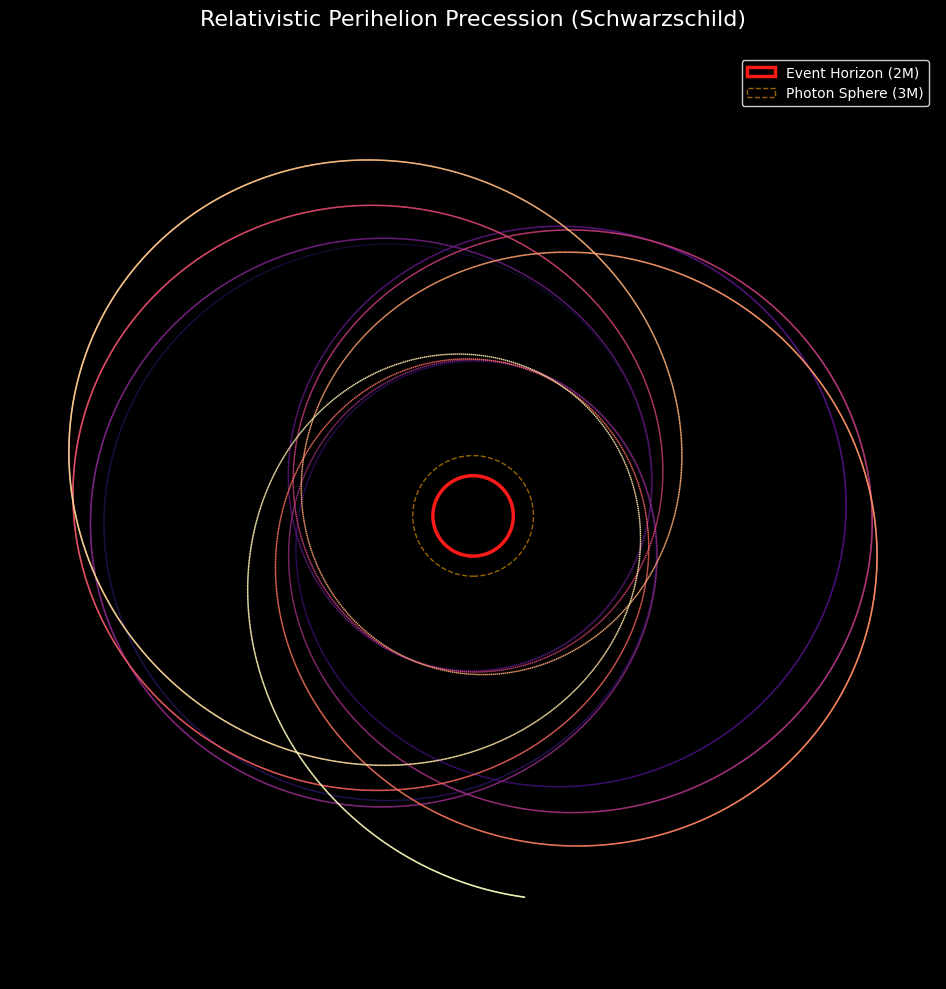

In [20]:
# Setup the canvas
plt.figure(figsize=(10, 10), facecolor='black')
plt.style.use('dark_background')

# 1. Plot the orbital path using a colormap tied to time
plt.scatter(x, y, c=proper_time, cmap='magma', s=1.5, alpha=0.9, edgecolor='none', zorder=1)

# 2. Draw the Event Horizon (r = 2M)
M_val = 1.0
horizon = plt.Circle((0, 0), 2*M_val, color='black', ec='#ff1a1a', lw=2.5, zorder=5, label="Event Horizon (2M)")
plt.gca().add_patch(horizon)

# 3. Draw the Photon Sphere (r = 3M)
photon_sphere = plt.Circle((0, 0), 3*M_val, color='none', ec='#ffaa00', lw=1, linestyle='--', alpha=0.6, zorder=4, label="Photon Sphere (3M)")
plt.gca().add_patch(photon_sphere)

# 4. Dynamic Auto-Scaling and Formatting
# Find the maximum distance the particle reached and add a 10% margin
max_distance = np.max(r_sol) * 1.10 

ax = plt.gca()
ax.set_aspect('equal') # Keep the geometry perfectly circular
ax.set_xlim(-max_distance, max_distance)
ax.set_ylim(-max_distance, max_distance)
ax.axis('off') # Hide the axes numbers for a cleaner look

plt.title("Relativistic Perihelion Precession (Schwarzschild)", color="white", fontsize=16, pad=20)
plt.legend(loc="upper right", facecolor='black', edgecolor='white', labelcolor='white')

# Render the plot
plt.tight_layout()
plt.show()